# 01 — Découvrez les blocs de construction du Reinforcement Learning

Dans cet exercice, on va interagir pour la première fois avec un environnement de RL. L'objectif : comprendre le cycle fondamental qui est au cœur de toute l'IA de jeu et de robotique.

```
Observation → Agent → Action → Environnement → Récompense + Nouvelle observation → ...
```


## 1. C'est quoi le Reinforcement Learning ?

Le **Reinforcement Learning (RL)** est un paradigme d'apprentissage où un **agent** apprend en interagissant avec un **environnement**. Il n'y a pas de "bonne réponse" fournie à l'avance : l'agent découvre ce qui fonctionne par essai-erreur, guidé uniquement par des **récompenses**.

### Les 3 composants fondamentaux

| Composant               | Rôle                                   | Exemple (CartPole)                            |
| ----------------------- | -------------------------------------- | --------------------------------------------- |
| **Agent**               | Prend les décisions                    | Le "joueur" qui contrôle le chariot           |
| **Environnement**       | Le monde dans lequel l'agent agit      | La simulation du chariot + perche             |
| **Récompense (reward)** | Signal de feedback après chaque action | +1 à chaque instant où la perche reste debout |

### Le cycle RL

```
┌─────────────────────────────────────────────────────┐
│                                                     │
│   Agent ──────────── Action ──────────▶ Environnement │
│     ▲                                       │       │
│     │           Observation + Reward         │       │
│     └───────────────────────────────────────┘       │
│                                                     │
└─────────────────────────────────────────────────────┘
```

À chaque **pas de temps (timestep)** :

1. L'agent **observe** l'état de l'environnement
2. Il choisit une **action**
3. L'environnement lui renvoie une **récompense** et une **nouvelle observation**
4. On recommence jusqu'à la fin de l'**épisode**


## 2. L'environnement CartPole-v1

### Description du problème

Un chariot peut se déplacer à gauche ou à droite sur un rail. Une perche est fixée dessus par une charnière. L'objectif : **empêcher la perche de tomber** le plus longtemps possible en déplaçant le chariot.

```
         |
         |  ← Perche (doit rester verticale)
         |
    ┌────┴────┐
    │ Chariot │────── Rail ──────
    └────┬────┘
    ←  Gauche / Droite →
```

### Pourquoi CartPole est-il un classique ?

- Simple à comprendre visuellement
- Espace d'observation continu (vecteur de 4 nombres)
- Espace d'action discret (2 choix seulement)
- Résolvable rapidement → idéal pour tester des algorithmes


## Étape 1 — Créer l'environnement et explorer ses propriétés


In [2]:
import gymnasium as gym
import numpy as np

# Créer l'environnement CartPole-v1
# gym.make() instancie l'environnement par son nom
env = gym.make("CartPole-v1")

print("Environnement créé :", env)

Environnement créé : <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>


### L'espace d'observation : ce que l'agent "voit"

L'**espace d'observation** (`observation_space`) décrit la forme et les limites de ce que l'agent perçoit à chaque pas de temps.

Pour CartPole, l'agent reçoit un vecteur de **4 nombres** :

| Index | Variable | Signification                   | Limites         |
| ----- | -------- | ------------------------------- | --------------- |
| 0     | `x`      | Position du chariot sur le rail | ≈ [-4.8, 4.8]   |
| 1     | `ẋ`      | Vitesse du chariot              | ≈ [-∞, +∞]      |
| 2     | `θ`      | Angle de la perche (radians)    | ≈ [-0.42, 0.42] |
| 3     | `θ̇`      | Vitesse angulaire de la perche  | ≈ [-∞, +∞]      |

Le type `Box` signifie un espace **continu** : chaque valeur peut prendre n'importe quel nombre réel dans un intervalle.


In [3]:
print("=== Espace d'OBSERVATION ===")
print(f"Type      : {env.observation_space}")
print(
    f"Shape     : {env.observation_space.shape}  → vecteur de {env.observation_space.shape[0]} valeurs"
)
print(f"Min       : {env.observation_space.low}")
print(f"Max       : {env.observation_space.high}")

print()
print("Exemple d'observation aléatoire :")
obs_exemple = env.observation_space.sample()
labels = [
    "Position chariot",
    "Vitesse chariot",
    "Angle perche (rad)",
    "Vitesse angulaire perche",
]
for label, val in zip(labels, obs_exemple):
    print(f"  {label:<28} : {val:+.4f}")

=== Espace d'OBSERVATION ===
Type      : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Shape     : (4,)  → vecteur de 4 valeurs
Min       : [-4.8               -inf -0.41887903        -inf]
Max       : [4.8               inf 0.41887903        inf]

Exemple d'observation aléatoire :
  Position chariot             : +0.9759
  Vitesse chariot              : -0.6553
  Angle perche (rad)           : -0.1144
  Vitesse angulaire perche     : +1.0682


### L'espace d'action : ce que l'agent "peut faire"

L'**espace d'action** (`action_space`) décrit les choix disponibles pour l'agent.

Pour CartPole, il n'y a que **2 actions possibles** :

| Action | Valeur | Effet                             |
| ------ | ------ | --------------------------------- |
| Gauche | 0      | Pousser le chariot vers la gauche |
| Droite | 1      | Pousser le chariot vers la droite |

Le type `Discrete` signifie un espace **discret** : un ensemble fini de valeurs entières.

> **Box vs Discrete** : c'est une distinction fondamentale en RL. Box = continu (infinité de valeurs possibles, ex: vitesse d'un moteur). Discrete = discret (nombre fini de choix, ex: tourner à gauche ou à droite). Certains algorithmes ne fonctionnent qu'avec l'un ou l'autre.


In [4]:
print("=== Espace d'ACTION ===")
print(f"Type             : {env.action_space}")
print(f"Nombre d'actions : {env.action_space.n}")

print()
print("Actions possibles :")
print("  0 → Pousser le chariot à GAUCHE")
print("  1 → Pousser le chariot à DROITE")

print()
print("Exemples d'actions aléatoires (5 tirages) :")
for _ in range(5):
    action = env.action_space.sample()
    direction = "GAUCHE" if action == 0 else "DROITE"
    print(f"  action={action} → {direction}")

=== Espace d'ACTION ===
Type             : Discrete(2)
Nombre d'actions : 2

Actions possibles :
  0 → Pousser le chariot à GAUCHE
  1 → Pousser le chariot à DROITE

Exemples d'actions aléatoires (5 tirages) :
  action=1 → DROITE
  action=0 → GAUCHE
  action=0 → GAUCHE
  action=1 → DROITE
  action=0 → GAUCHE


### Récapitulatif : Box vs Discrete

| Espace        | Type    | Exemple              | Compatible avec  |
| ------------- | ------- | -------------------- | ---------------- |
| `Box(4,)`     | Continu | Position, vitesse... | PPO, A2C, SAC... |
| `Discrete(2)` | Discret | 0 ou 1               | PPO, A2C, DQN... |
| `Discrete(4)` | Discret | 0, 1, 2 ou 3         | PPO, A2C, DQN... |

CartPole a :

- **Observation** : `Box(4,)` → espace continu
- **Action** : `Discrete(2)` → espace discret

Cette combinaison est compatible avec PPO, A2C et DQN (pas SAC/DDPG qui nécessitent des actions continues).


## Étape 2 — Un agent aléatoire sur 10 épisodes

Avant d'entraîner quoi que ce soit, on va observer les performances d'un agent **complètement aléatoire** : à chaque pas, il tire une action au hasard (gauche ou droite).

### Vocabulaire clé

| Terme                       | Définition                                                                     |
| --------------------------- | ------------------------------------------------------------------------------ |
| **Épisode**                 | Une partie complète, du début (reset) jusqu'à la fin (perche tombe ou timeout) |
| **Pas de temps (timestep)** | Un seul cycle observation → action → récompense                                |
| **Récompense cumulée**      | Somme de toutes les récompenses d'un épisode                                   |
| `terminated`                | L'épisode s'est terminé pour une raison logique (perche tombée, chariot sorti) |
| `truncated`                 | L'épisode s'est terminé car on a atteint la limite de temps (500 steps)        |

> Dans CartPole, la récompense est **+1 à chaque pas de temps**. Donc la récompense cumulée = nombre de steps avant l'échec. Le maximum est **500** (limite de CartPole-v1).


In [5]:
# Recréer l'environnement (bonne pratique : partir d'un état propre)
env = gym.make("CartPole-v1")

N_EPISODES = 10

print(f"Simulation de {N_EPISODES} épisodes avec un agent ALÉATOIRE")
print("=" * 50)

for episode in range(1, N_EPISODES + 1):
    # --- Début de l'épisode ---
    # reset() réinitialise l'environnement et retourne la première observation
    # Nouvelle API gymnasium : retourne (observation, info)
    observation, info = env.reset()

    total_reward = 0
    terminated = False
    truncated = False
    n_steps = 0

    # --- Boucle interne : un pas de temps à la fois ---
    while not (terminated or truncated):
        # Choisir une action aléatoire (0 ou 1)
        action = env.action_space.sample()

        # Appliquer l'action à l'environnement
        # step() retourne 5 valeurs (nouvelle API gymnasium)
        observation, reward, terminated, truncated, info = env.step(action)

        # Accumuler la récompense
        total_reward += reward
        n_steps += 1

    # --- Fin de l'épisode ---
    raison = "timeout" if truncated else "perche tombée"
    print(
        f"Épisode {episode:2d} | Steps : {n_steps:3d} | Reward total : {total_reward:.0f} | Fin : {raison}"
    )

# Toujours fermer l'environnement quand on a fini
env.close()
print("\nEnvironnement fermé.")

Simulation de 10 épisodes avec un agent ALÉATOIRE
Épisode  1 | Steps :  11 | Reward total : 11 | Fin : perche tombée
Épisode  2 | Steps :  28 | Reward total : 28 | Fin : perche tombée
Épisode  3 | Steps :  33 | Reward total : 33 | Fin : perche tombée
Épisode  4 | Steps :  13 | Reward total : 13 | Fin : perche tombée
Épisode  5 | Steps :  36 | Reward total : 36 | Fin : perche tombée
Épisode  6 | Steps :  28 | Reward total : 28 | Fin : perche tombée
Épisode  7 | Steps :  20 | Reward total : 20 | Fin : perche tombée
Épisode  8 | Steps :  15 | Reward total : 15 | Fin : perche tombée
Épisode  9 | Steps :  12 | Reward total : 12 | Fin : perche tombée
Épisode 10 | Steps :  22 | Reward total : 22 | Fin : perche tombée

Environnement fermé.


### Analyse des résultats

Un agent aléatoire obtient en général entre **10 et 50 steps** avant que la perche tombe. C'est notre **baseline** : la performance minimale à dépasser avec un vrai algorithme.

### Les 5 valeurs de `env.step(action)`

| Valeur        | Type         | Signification                                       |
| ------------- | ------------ | --------------------------------------------------- |
| `observation` | `np.ndarray` | Nouvel état de l'environnement                      |
| `reward`      | `float`      | Récompense reçue (+1.0 à chaque step dans CartPole) |
| `terminated`  | `bool`       | Épisode terminé pour une raison logique             |
| `truncated`   | `bool`       | Épisode terminé par timeout                         |
| `info`        | `dict`       | Infos supplémentaires (souvent vide ou debug)       |

> **Attention aux vieilles versions** : l'ancienne API (`gym`, pas `gymnasium`) retournait seulement 4 valeurs : `obs, reward, done, info`. Le `done` combinait `terminated` et `truncated`. Aujourd'hui, avec `gymnasium`, on les reçoit séparément.


## 3. Bonus — Statistiques sur 100 épisodes

Pour avoir une idée plus précise des performances de l'agent aléatoire, on peut faire tourner 100 épisodes et calculer la moyenne.


Agent aléatoire sur 100 épisodes :
  Reward moyen : 20.8
  Reward min   : 9
  Reward max   : 57
  (rappel : le maximum possible est 500)


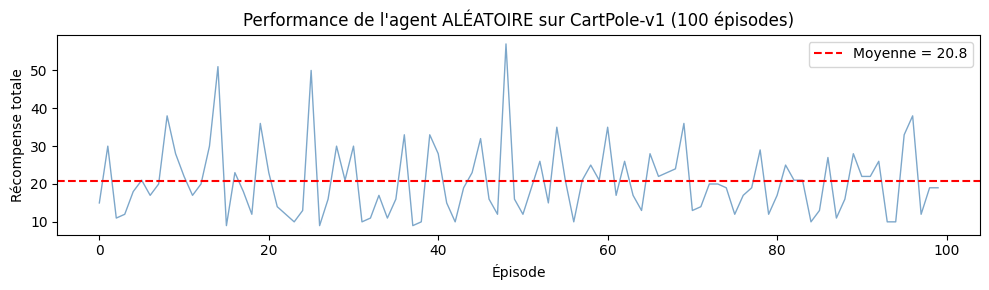

In [6]:
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")

rewards = []

for _ in range(100):
    obs, info = env.reset()
    total = 0
    done = False

    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total += reward
        done = terminated or truncated

    rewards.append(total)

env.close()

print(f"Agent aléatoire sur 100 épisodes :")
print(f"  Reward moyen : {np.mean(rewards):.1f}")
print(f"  Reward min   : {np.min(rewards):.0f}")
print(f"  Reward max   : {np.max(rewards):.0f}")
print(f"  (rappel : le maximum possible est 500)")

# Visualisation
plt.figure(figsize=(10, 3))
plt.plot(rewards, color="steelblue", alpha=0.7, linewidth=1)
plt.axhline(
    np.mean(rewards),
    color="red",
    linestyle="--",
    label=f"Moyenne = {np.mean(rewards):.1f}",
)
plt.xlabel("Épisode")
plt.ylabel("Récompense totale")
plt.title("Performance de l'agent ALÉATOIRE sur CartPole-v1 (100 épisodes)")
plt.legend()
plt.tight_layout()
plt.show()

## Résumé

| Concept                     | Détail                                                                      |
| --------------------------- | --------------------------------------------------------------------------- |
| `gym.make("CartPole-v1")`   | Crée l'environnement                                                        |
| `env.observation_space`     | Décrit ce que l'agent perçoit (`Box` = continu)                             |
| `env.action_space`          | Décrit ce que l'agent peut faire (`Discrete` = discret)                     |
| `env.reset()`               | Démarre un nouvel épisode → retourne `(obs, info)`                          |
| `env.step(action)`          | Applique une action → retourne `(obs, reward, terminated, truncated, info)` |
| `env.action_space.sample()` | Tire une action aléatoire                                                   |
| `env.close()`               | Libère les ressources                                                       |

### Ce qu'on a appris

- Un agent **aléatoire** tient en moyenne **~20-25 steps** sur CartPole-v1
- Le **maximum** de récompense est 500 (timeout)
- Ce score de ~20 est notre **baseline** : un algorithme de RL doit faire **beaucoup mieux**

**Prochaine étape** : entraîner un agent avec Q-Learning → `OC/2. q-learning/`
